In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from epieconlib import *
import scipy.optimize
from scipy.stats import sem
import warnings
import os

In [2]:
A_OPT = True # Generates a_opt vs theta Fig.
A_EQ = True  # Generates a_eq vs alpha Fig.
MF = True
FARBOODI = True
HMF = True
R_INF = True # Generates r_inf vs alpha Fig.
I_INF = True
I_MAX = True
EPI_CURVES = True

In [3]:
dt = 1
a_steps = 10

# Population

N_tot = int(10000)
i0 = 0.01
delta = np.exp(-dt/10) # discount factor (decay time of ~10 days)

# Biological Parameters

mu = dt / 10 # Recovery rate (infection lasts ~10 days)
R0 = 3.
beta = R0*mu # Technically it's beta*<k>

# CODE PARAMETERS

zero_tol = 1e-9  # value of i considered to be 0
t_max = round(1000/dt) # max lenght of simulations

# Colors
c1 = "#198ed5ff" # blue
c2 = "#b10d0dff" # red

# Range

alpha_grid = np.hstack((0,np.geomspace(0.1, 1000, 32)))

In [4]:
# (Annealed) network generation

k_min = 5                  # min degree
k_max = int(N_tot**(0.5))  # max degree
gamma = 2.1                # power law exponent p_k = C*k^{-gamma}

degrees, p_k = create_annealed_network(k_min, k_max, gamma)

In [5]:
def colorFader(c1, c2, opacity=1, mix=0): #fade (linear interpolate) from color c1 (at mix=0) to c2 (mix=1)
    color1=np.array(mpl.colors.to_rgba(c1))
    color1[3] *= opacity
    color2=np.array(mpl.colors.to_rgba(c2))
    color2[3] *= opacity
    return mpl.colors.to_hex(mix*color1 + (1-mix)*color2, keep_alpha=True)

## Optimal social activity

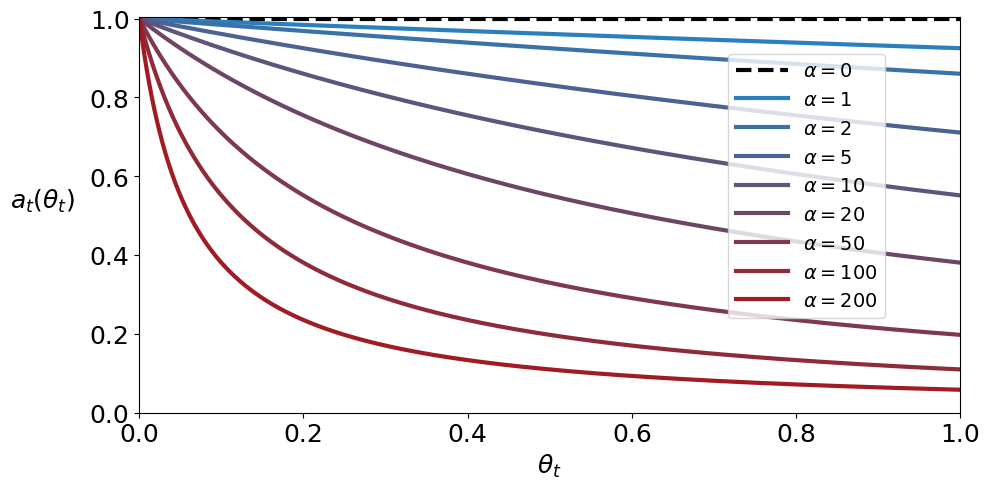

In [6]:
if A_OPT == True:
    
    fig, ax = plt.subplots(1, 1, figsize=(10,5))

    fontsize = 18

    ax.set_xlabel("$\\theta_t$", fontsize=fontsize)
    ax.set_ylabel("$a_t(\\theta_t)$", fontsize=fontsize, labelpad=34).set_rotation(0)
    ax.tick_params(axis='y', labelsize=fontsize)
    ax.tick_params(axis='x', labelsize=fontsize)

    alpha_list = np.array([0, 1, 2, 5, 10, 20, 50, 100, 200])

    thetas = np.linspace(0, 1, 1000)

    for idx, alpha in enumerate(alpha_list):
        
        a_list = [1 / (1 + delta*(alpha/dt)*beta*0.3*theta) for theta in thetas]  

        if alpha == 0:
            linestyle = "dashed"
            color = "black"
            label = "$\\alpha = 0$"
        else:  
            linestyle = "solid"
            color = colorFader(c2, c1, 1, idx/len(alpha_list))
            label = "$\\alpha = {}$".format(alpha)

        linewidth = 3

        ax.plot(thetas, a_list, label = label, linestyle=linestyle,
                color=color, linewidth=linewidth)
        
    #ax.text(0.5, .8, "$\delta={}$".format(delta),
    #        horizontalalignment='center',
    #        color = "k",
    #        fontsize=24)    
    
    plt.xlim(0,1)
    plt.ylim(0,1.005)
    fig.legend(prop={'size': 14}, handlelength=2.66, bbox_to_anchor=(0.9, 0.9))
    plt.tight_layout()
    plt.savefig("../Figures/a_opt/a_opt.pdf")
    plt.show()

# Equivalent social activity

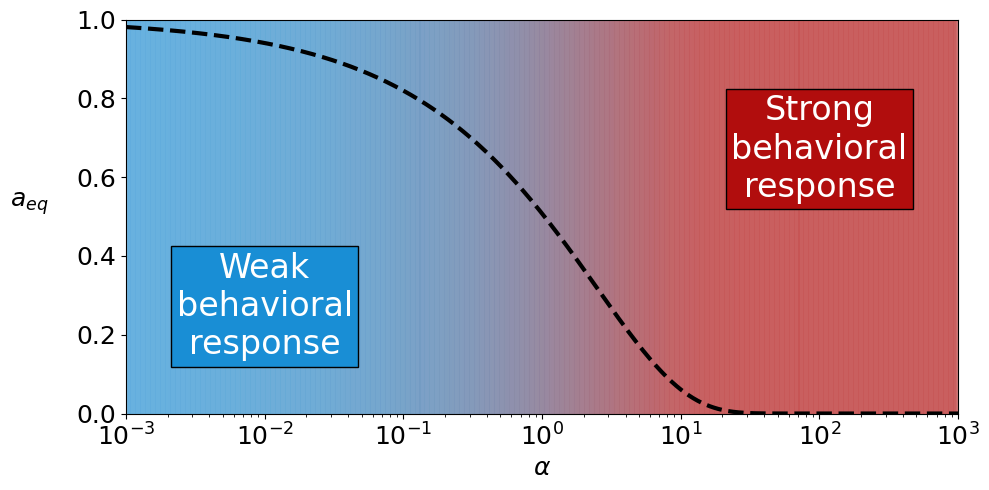

In [7]:
if A_EQ == True:

    def opt_fun(x, U_I):
        # Numerically find a_eq as the minimum of opt_fun
        return ( (np.log(x) - x + 1) + U_I)**2

    alpha_grid = np.geomspace(1e-3/dt, 1e3/dt, 1000)
    U_I_grid = (1-delta*(1-mu))*alpha_grid
    
    fig, ax = plt.subplots(1, 1, figsize=(10,5))

    fontsize = 18

    ax.set_xlabel("$\\alpha$", fontsize=fontsize)
    ax.set_ylabel(r"$a_{eq}$", fontsize=fontsize, labelpad=34).set_rotation(0)
    ax.tick_params(axis='y', labelsize=fontsize)
    ax.tick_params(axis='x', labelsize=fontsize)

    # Calculate with U_I but plot corresponding alpha
    a_equiv = [scipy.optimize.fminbound(opt_fun, x1=0, x2=1, args=[U_I], disp=False, xtol=1e-15) for U_I in U_I_grid]
    ax.plot(alpha_grid, a_equiv, color="k", linestyle="dashed", linewidth=3, zorder=1)

    for i,x in enumerate(alpha_grid):
        ax.axvline(x, color=colorFader(c1, c2, 0.15, a_equiv[i]), linewidth=4, zorder=0)

    ax.text(1e-2/dt, .15, "Weak\nbehavioral\nresponse",
            horizontalalignment='center',
            color = "white",
            bbox=dict(facecolor=c1, alpha=1),
            fontsize=24)
    
    ax.text(1e2/dt, .55, "Strong\nbehavioral\nresponse",
            horizontalalignment='center',
            color = "white",
            bbox=dict(facecolor=c2, alpha=1),
            fontsize=24)  

    plt.xscale("log")
    plt.xlim(min(alpha_grid), max(alpha_grid))
    plt.ylim(0, 1)
    #ax.legend(prop={'size': 18}, handlelength=2.66)

    plt.tight_layout()
    plt.savefig("../Figures/a_eq/a_eq.pdf")
    plt.show()

## MF

In [8]:
def simulate_farboodi(t_max=round(1000/dt), beta= 0.3+ 1/7, mu=1/7, alpha=197, delta=0.998, i0=5.27e-05, r0=2.51e-05):
    
    Y_list = []
    a_list = []
    
    eradicated = False

    tt = np.arange(0, t_max+dt, dt)
    
    Y = np.array([i0, 2.51e-05]) #initial condition Y[0] = i, Y[1] = r
    a = 1
    
    for idx, t in enumerate(tt):
        
        s = 1 - Y[0] -Y[1]

        for _ in range(a_steps):
            a = 1 / (1 + s*delta*beta*(alpha/dt)*a*Y[0])
        
        if Y[0] < zero_tol:
            # If I = 0 the epidemic is over
            eradicated = True
            tt = tt[0:idx]
            break
        else:
            Y_list.append(Y)
            a_list.append(a)
        
        Y = step_MF_sir(Y, beta, mu, a)
    
    Y_array = np.array(Y_list)
    a_time_series = np.array(a_list)
    
    time_series = {"s": 1 - Y_array[:,0] - Y_array[:,1],
                   "i": Y_array[:,0],
                   "r": Y_array[:,1]
                  }

    return tt, time_series, a_time_series, eradicated

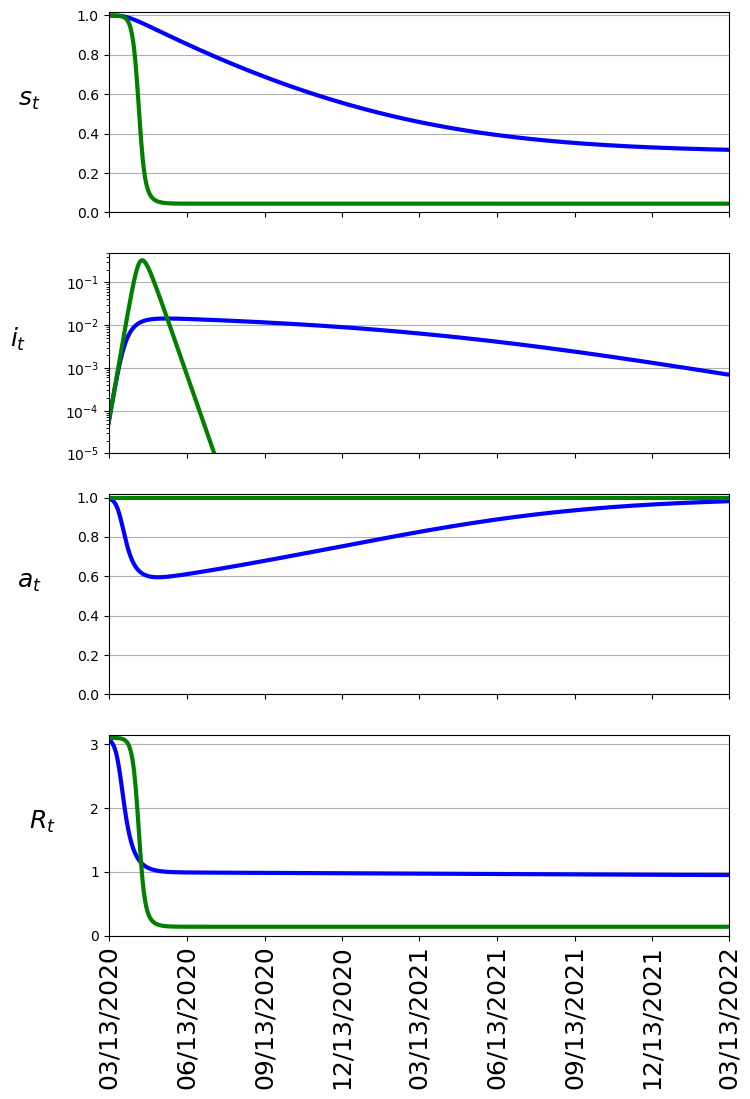

In [9]:
if FARBOODI == True:

    # comparison with the model of Farboodi et al. (2020) https://www.nber.org/papers/w27059

    fontsize = 18
    linewidth = 3

    fig, ax = plt.subplots(4,1, figsize=(8,12), sharex=True)

    # s
    # set ylim
    ax[0].set_ylim(0,1.02)
    ax[0].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax[0].set_ylabel("$s_t$", fontsize=fontsize, labelpad=34).set_rotation(0)
    # i
    ax[1].set_yscale("log")
    ax[1].set_yscale("log")
    ax[1].set_ylim(1e-5, 0.5)
    ax[1].set_yticks([1e-1, 1e-2, 1e-3, 1e-4, 1e-5,])
    ax[1].set_ylabel("$i_t$", fontsize=fontsize, labelpad=34).set_rotation(0)
    # a
    ax[2].set_ylim(0,1.02)
    ax[2].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax[2].set_ylabel("$a_t$", fontsize=fontsize, labelpad=34).set_rotation(0)
    # R
    ax[3].set_ylim(0,3.15)
    ax[3].set_yticks([0, 1, 2, 3])
    ax[3].set_ylabel("$R_t$", fontsize=fontsize, labelpad=34).set_rotation(0)
    dates = [mpl.dates.datestr2num("03/13/2020"),
            mpl.dates.datestr2num("06/13/2020"),
            mpl.dates.datestr2num("09/13/2020"),
            mpl.dates.datestr2num("12/13/2020"),
            mpl.dates.datestr2num("03/13/2021"),
            mpl.dates.datestr2num("06/13/2021"),
            mpl.dates.datestr2num("09/13/2021"),
            mpl.dates.datestr2num("12/13/2021"),
            mpl.dates.datestr2num("03/13/2022")]
    ax[3].set_xticks(dates)
    ax[3].set_xticklabels(["03/13/2020", "06/13/2020", "09/13/2020", "12/13/2020", "03/13/2021", "06/13/2021", "09/13/2021", "12/13/2021", "03/13/2022"])
    ax[3].tick_params(axis='x', labelsize=fontsize, rotation=90)
    ax[3].set_xlim(dates[0], dates[-1])


    # Laissez-Faire
    
    delta = np.exp(-0.72/365)
    
    tt, equilibrium, a_eq, eradicated = simulate_farboodi(alpha=197)
    
    # make tt into dates starting from 03/13/2020
    # use format mm/dd/yyyy

    start_date = "03/13/2020"
    start_date = mpl.dates.datestr2num(start_date)
    tt = start_date + tt
    
    # s
    ax[0].plot(tt, equilibrium["s"], color="b", linewidth=linewidth, label="$i_t$")
    # i
    ax[1].plot(tt, equilibrium["i"], color="b", linewidth=linewidth, label="$i_t$")
    # a
    ax[2].plot(tt, a_eq, color="b", linewidth=linewidth, label="$a_t$")
    # R
    ax[3].plot(tt, (0.3 + 1/7) / (1/7)*a_eq*a_eq*equilibrium["s"], color="b", linewidth=linewidth, label="$a_t$")
    
    # SIR
    
    delta = np.exp(-0.72/365)
    
    _, sird, a_sird, eradicated = simulate_farboodi(alpha=0)
    
    # pad a with last value so it has the same length as tt
    a_sird = np.pad(a_sird, (0, len(tt)-len(a_sird)), 'edge')
    # pad result s,i and r with last value so it has the same length as tt
    sird["s"] = np.pad(sird["s"], (0, len(tt)-len(sird["s"])), 'edge')
    sird["i"] = np.pad(sird["i"], (0, len(tt)-len(sird["i"])), 'edge')
    sird["r"] = np.pad(sird["r"], (0, len(tt)-len(sird["r"])), 'edge')
    a_sird = np.pad(a_sird, (0, len(tt)-len(a_sird)), 'edge')

    # s
    ax[0].plot(tt, sird["s"], color="green", linewidth=linewidth, label="$i_t$")
    # i
    ax[1].plot(tt, sird["i"], color="green", linewidth=linewidth, label="$i_t$")
    # a
    ax[2].plot(tt, a_sird, color="green", linewidth=linewidth, label="$a_t$")
    # R
    ax[3].plot(tt, 3.1*a_sird*a_sird*sird["s"], color="green", linewidth=linewidth, label="$a_t$")
    #ax[3].set_ylim(0.8, 1.2)
    
        #fig.legend(prop={'size': 14}, handlelength=2.66, bbox_to_anchor=(0.87, 0.85))
    
    for axis in ax:
        axis.grid(axis='y')

In [10]:
print("Min Rt: ", min((0.3 + 1/7) / (1/7)*a_eq*a_eq*equilibrium["s"]))

Min Rt:  0.9467440219729334


In [11]:
if FARBOODI == True:
    u = (1-np.exp(-0.72/365)*(1-1/7))*197 # corresponding to alpha = 197
    a_eq = scipy.optimize.fminbound(opt_fun, x1=0, x2=1, args=[u], disp=False, xtol=1e-15)
    print(a_eq)

1.5801636824447066e-13


In [12]:
max(sird["i"]) - max(equilibrium["i"]) / max(sird["i"])

np.float64(0.2868393546308767)

In [13]:
max(sird["i"]) - 0.026 / max(sird["i"])

np.float64(0.25153392753184145)

In [14]:
0.026 / max(sird["i"])

np.float64(0.07872589472771571)

In [66]:
truth = pd.read_csv('../Data/Truth/truth-Cumulative Deaths.csv')
truth = truth.query('location_name == "United States"')

/tmp/ipykernel_10218/3296535485.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  truth = pd.read_csv('../Data/Truth/truth-Cumulative Deaths.csv')


In [67]:
start = truth[truth['date'] == '2020-03-13'].index.values[0]
end  = truth[truth['date'] == '2020-07-03'].index.values[0]

In [68]:
truth = truth[(truth.index >= start) & (truth.index < end)]

In [69]:
truth.index = tt[:len(truth)].astype(int)

In [70]:
truth

,date,location,location_name,value
18334,2020-03-13,US,United States,52
18335,2020-03-14,US,United States,61
18336,2020-03-15,US,United States,72
18337,2020-03-16,US,United States,97
18338,2020-03-17,US,United States,133
...,...,...,...,...
18441,2020-06-28,US,United States,126512
18442,2020-06-29,US,United States,126881
18443,2020-06-30,US,United States,127430
18444,2020-07-01,US,United States,128132


In [89]:
# Import required libraries
import os
import numpy as np

# Define the parent directory
parent_dir = 'output_prova/comparison'
recovered = {}

# Populate the fatalities dictionary
for dirs in os.listdir(parent_dir):
    sim_dir = os.path.join(parent_dir, dirs)
    l_vs_g = dirs.split('=')[-1]  # Extract the key as a string
    recovered[l_vs_g] = np.load(os.path.join(sim_dir, 'recovered.npy'))

# Sort the keys of fatalities dictionary numerically (convert to float for sorting)
#sorted_keys = sorted(fatalities.keys(), key=lambda x: float(x))
#
## If you want the sorted keys in string format, you can keep them as is
#print(sorted_keys)
#
## Optionally, if you want to access the values in the sorted order:
#fatalities = {key: fatalities[key] for key in sorted_keys}

In [92]:
recovered['0.0']

array([[6.20000e-07, 6.20000e-07, 6.20000e-07, ..., 9.21320e-04,
        9.35580e-04, 9.47360e-04],
       [6.20000e-07, 6.20000e-07, 6.20000e-07, ..., 1.02672e-03,
        1.03602e-03, 1.04718e-03],
       [6.20000e-07, 6.20000e-07, 6.20000e-07, ..., 1.24000e-06,
        1.24000e-06, 1.24000e-06],
       ...,
       [6.20000e-07, 6.20000e-07, 1.24000e-06, ..., 9.27520e-04,
        9.34960e-04, 9.43020e-04],
       [6.20000e-07, 6.20000e-07, 6.20000e-07, ..., 8.71100e-04,
        8.78540e-04, 8.90940e-04],
       [6.20000e-07, 1.24000e-06, 1.24000e-06, ..., 1.24000e-06,
        1.24000e-06, 1.24000e-06]])

In [78]:
np.load(os.path.join(sim_dir, 'fatalities.npy'))

array([[6.2000e-07, 6.2000e-07, 6.2000e-07, ..., 1.9344e-04, 1.9530e-04,
        1.9778e-04],
       [6.2000e-07, 6.2000e-07, 6.2000e-07, ..., 6.2000e-06, 6.2000e-06,
        6.2000e-06],
       [6.2000e-07, 6.2000e-07, 6.2000e-07, ..., 3.2488e-04, 3.3170e-04,
        3.3914e-04],
       ...,
       [6.2000e-07, 6.2000e-07, 6.2000e-07, ..., 2.7342e-04, 2.7652e-04,
        2.7962e-04],
       [6.2000e-07, 6.2000e-07, 6.2000e-07, ..., 2.3808e-04, 2.4118e-04,
        2.4924e-04],
       [6.2000e-07, 6.2000e-07, 6.2000e-07, ..., 3.7200e-06, 3.7200e-06,
        3.7200e-06]])

In [86]:
328e6*1.555e-7

51.004000000000005

In [85]:
N_US == 328e6

True

In [80]:
N_US*val

array([ 1.260832,  1.260832,  1.260832,  1.891248,  2.521664,  2.521664,
        2.521664,  2.521664,  2.521664,  2.521664,  2.521664,  2.521664,
        2.521664,  3.15208 ,  3.15208 ,  3.782496,  3.782496,  4.412912,
        5.043328,  6.30416 ,  6.30416 ,  6.934576,  7.564992,  8.195408,
        8.195408,  8.825824,  8.825824,  8.825824, 10.086656, 12.60832 ,
       12.60832 , 13.869152, 15.7604  , 17.021232, 17.021232, 17.651648,
       20.173312, 20.173312, 22.06456 , 22.06456 , 22.06456 , 22.06456 ,
       22.06456 , 22.06456 , 24.586224, 25.21664 , 25.847056, 25.847056,
       25.847056, 26.477472, 27.107888, 27.107888, 27.738304, 27.738304,
       27.738304, 28.36872 , 28.36872 , 28.36872 , 28.999136, 28.999136,
       28.999136, 28.999136, 28.999136, 28.999136, 28.999136, 28.999136,
       28.999136, 28.999136, 28.999136, 28.999136, 28.999136, 28.999136,
       28.999136, 28.999136, 28.999136, 28.999136, 28.999136, 28.999136,
       28.999136, 28.999136, 28.999136, 28.999136, 

(18334.0, 18446.0)

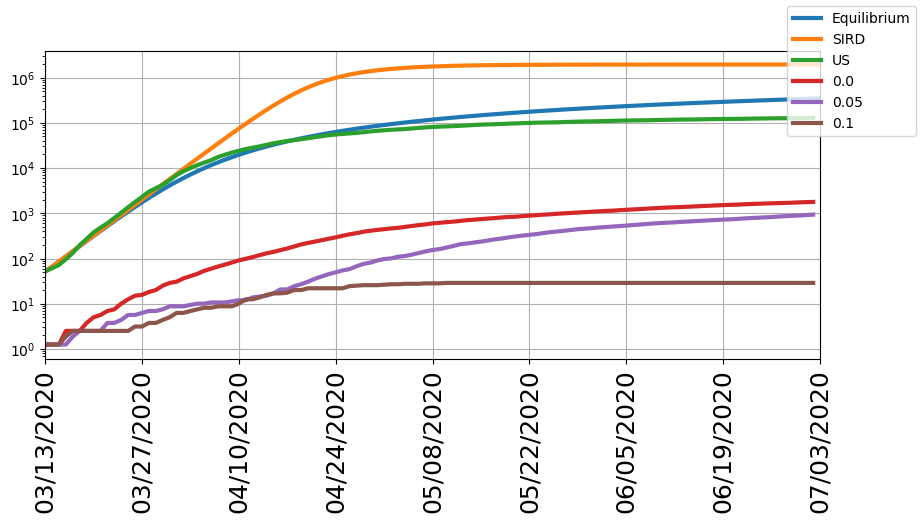

In [79]:
fig, ax = plt.subplots(1,1, figsize=(10,4))

pi = 0.0062 # fatalty rate

N_US = 328e6

# plot fatalties in the US (Equilibrium and SIRD)
ax.plot(tt, N_US*pi*equilibrium["r"], linewidth=linewidth, label="Equilibrium") # Equilibrium
ax.plot(tt, N_US*pi*sird["r"], linewidth=linewidth, label="SIRD") # SIRD
ax.plot(truth.index, truth.value, linewidth=linewidth, label="US") # SIRD
for key, val in list(fatalities.items())[:3]:
    ax.plot(truth.index, N_US*val, linewidth=linewidth, label=key) # SIRD
ax.set_yscale("log")
ax.grid()
fig.legend()


dates_fat = [mpl.dates.datestr2num("03/13/2020"),
            mpl.dates.datestr2num("03/27/2020"),
            mpl.dates.datestr2num("04/10/2020"),
            mpl.dates.datestr2num("04/24/2020"),
            mpl.dates.datestr2num("05/08/2020"),
            mpl.dates.datestr2num("05/22/2020"),
            mpl.dates.datestr2num("06/05/2020"),
            mpl.dates.datestr2num("06/19/2020"),
            mpl.dates.datestr2num("07/03/2020")]
ax.set_xticks(dates_fat)
ax.set_xticklabels(["03/13/2020", "03/27/2020", "04/10/2020", "04/24/2020", "05/08/2020", "05/22/2020", "06/05/2020", "06/19/2020", "07/03/2020"])
ax.tick_params(axis='x', labelsize=fontsize, rotation=90)
ax.set_xlim(dates_fat[0], dates_fat[-1])

In [42]:
truth

,date,location,location_name,value
18334,2020-03-14,US,United States,61
18335,2020-03-15,US,United States,72
18336,2020-03-16,US,United States,97
18337,2020-03-17,US,United States,133
18338,2020-03-18,US,United States,198
...,...,...,...,...
18441,2020-06-29,US,United States,126881
18442,2020-06-30,US,United States,127430
18443,2020-07-01,US,United States,128132
18444,2020-07-02,US,United States,128881


In [28]:
# fatalties on July 1st

day = mpl.dates.datestr2num("07/01/2020")

sird_july = 328e6*pi*sird["r"][np.where(tt == day)][0]
eq_july = 328e6*pi*equilibrium["r"][np.where(tt == day)][0]

# SIRD
print(f"SIRD: {sird_july}")
# Equilibrium
print(f"Equilibrium: {eq_july}")

SIRD: 1943244.8244630515
Equilibrium: 339031.6782113192


In [29]:
(sird_july - eq_july) / sird_july

np.float64(0.8255332143725128)

In [30]:
337423 / 564000

0.5982677304964539

In [31]:
equilibrium["r"][-1] / sird["r"][-1]

np.float64(0.7251752913291689)

(18334.0, 18446.0)

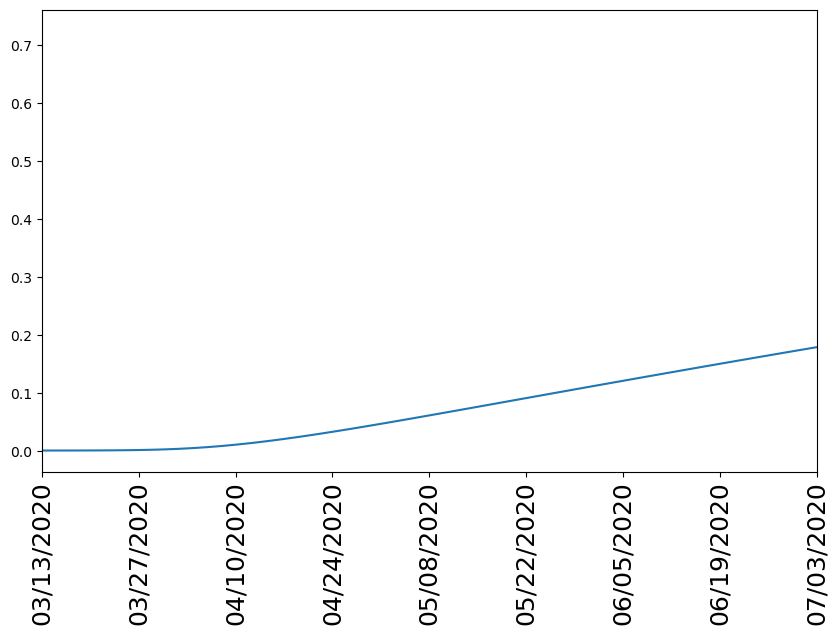

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(tt, equilibrium["r"]/sird["r"][-1])

ax.set_xticks(dates_fat)
ax.set_xticklabels(["03/13/2020", "03/27/2020", "04/10/2020", "04/24/2020", "05/08/2020", "05/22/2020", "06/05/2020", "06/19/2020", "07/03/2020"])
ax.tick_params(axis='x', labelsize=fontsize, rotation=90)
ax.set_xlim(dates_fat[0], dates_fat[-1])

In [33]:
eq_july / sird_july

np.float64(0.1744667856274872)

In [34]:
564000 / 1925000

0.29298701298701296

In [35]:
(sird_july - eq_july) / sird_july

np.float64(0.8255332143725128)

In [36]:
328e6*pi*sird["r"][np.where(tt == day)][0]

np.float64(1943244.8244630515)

## HMF

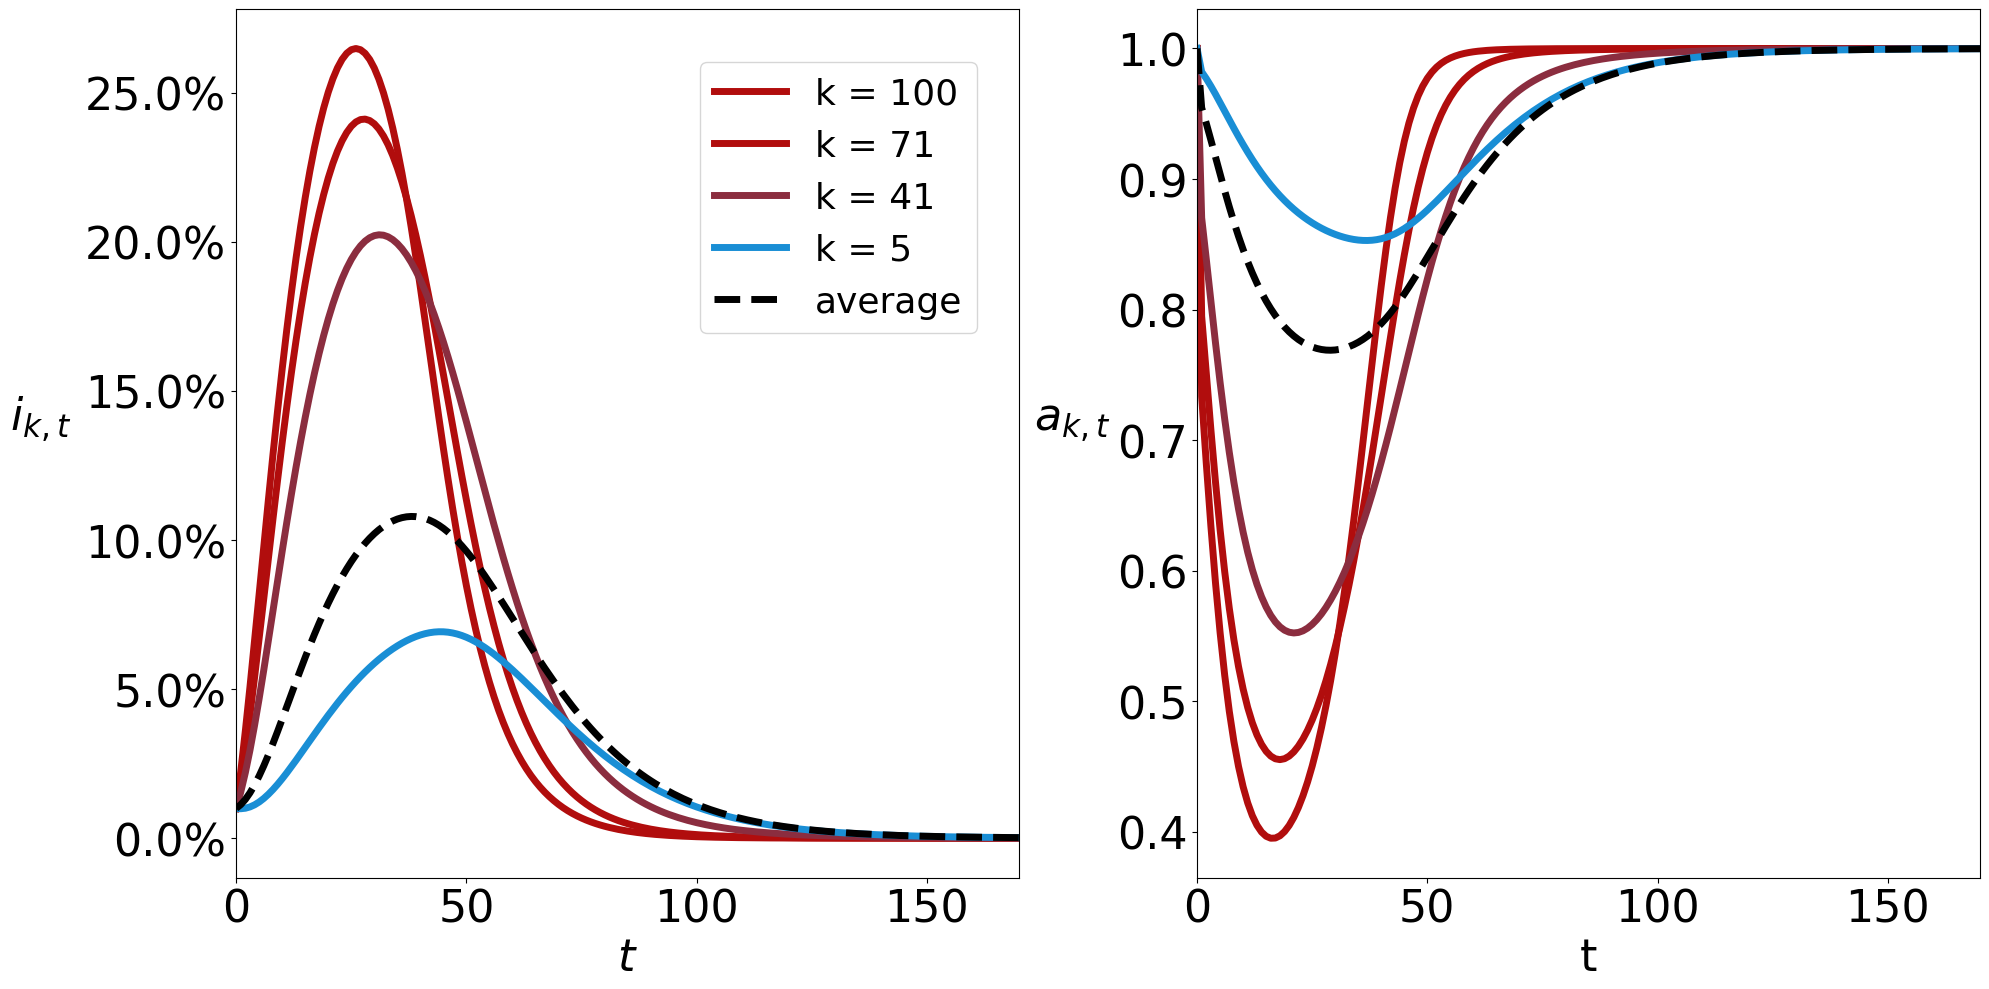

In [30]:
if HMF == True:

    linewidth = 5

    fig, ax = plt.subplots(1,2, figsize=(20,10))

    fontsize = 32
    padsize = 32
    ticksize = 32

    ax1 = ax[0]
    ax2 = ax[1]

    ax1.set_xlabel('$t$', fontsize = fontsize)
    ax1.set_ylabel(r'$i_{k,t}$', fontsize = fontsize, labelpad=fontsize).set_rotation(0)
    ax1.tick_params(axis='y', labelsize=ticksize)
    ax1.tick_params(axis='x', labelsize=ticksize)
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter()) #display "%" sign on y axis

    ax2.set_xlabel('t', fontsize = fontsize)
    ax2.set_ylabel(r'$a_{k,t}$', fontsize = fontsize, labelpad=fontsize).set_rotation(0)
    #ax2.set_ylim(0, 1)
    ax2.tick_params(axis='x', labelsize=fontsize)
    ax2.tick_params(axis='y', labelsize=fontsize)

    tt, result, a, theta, eradicated = simulate_HMF('sir', t_max, beta, mu, 20, delta, i0, degrees, p_k, a_steps, dt)

    if not eradicated:
        print("WARNING: tmax was reached")

    percent = {}

    for k_idx, k in enumerate(degrees):
        percent[k] = np.array([elem*100 for elem in result["i"][k]])  # Percentage of I

    kstep = 30

    ax1.plot(tt, percent[k_max], label="k = {}".format(k_max), color=c2, linewidth = linewidth) #Always display k_max
    ax2.plot(tt, a[k_max], color=c2, linestyle = "solid", linewidth = linewidth)
    for k_idx, k in enumerate(degrees[-kstep:kstep:-kstep]): # Plot only a fraction of all degrees
        color = colorFader(c1, c2, 1, k_idx/len(degrees[::-kstep]))
        ax1.plot(tt, percent[k], label="k = {}".format(k), color=color, linewidth = linewidth)
        ax2.plot(tt, a[k], color=color, linestyle = "solid", linewidth = linewidth)
    ax1.plot(tt, percent[k_min], label="k = {}".format(k_min), color=c1, linewidth = linewidth) #Always display k_min
    ax2.plot(tt, a[k_min], color=c1, linestyle = "solid", linewidth = linewidth)


    percent_tot = np.vstack(([np.pad(percent[k]*p_k[k],[(0, len(tt)-len(percent[k]))], mode='constant') # constant mode 
                          for k in degrees])).sum(axis=0)                                         # defaults to 0
    a_ave = np.vstack(([np.pad(a[k]*p_k[k],[(0, len(tt)-len(a[k]))], mode='constant')
                          for k in degrees])).sum(axis=0)

    ax1.plot(tt, percent_tot, color="k", linestyle = "dashed", linewidth = linewidth, label="average")  
    ax2.plot(tt, a_ave, color="k", linestyle = "dashed", linewidth = linewidth)

    fig.legend(bbox_to_anchor=(0.5, 0.95), prop={'size': 26})
    fig.tight_layout()  # otherwise the right y-label is slightly clipped   
    ax1.set_xlim(0, 170)
    ax2.set_xlim(0, 170)
    plt.show()

# Subplot

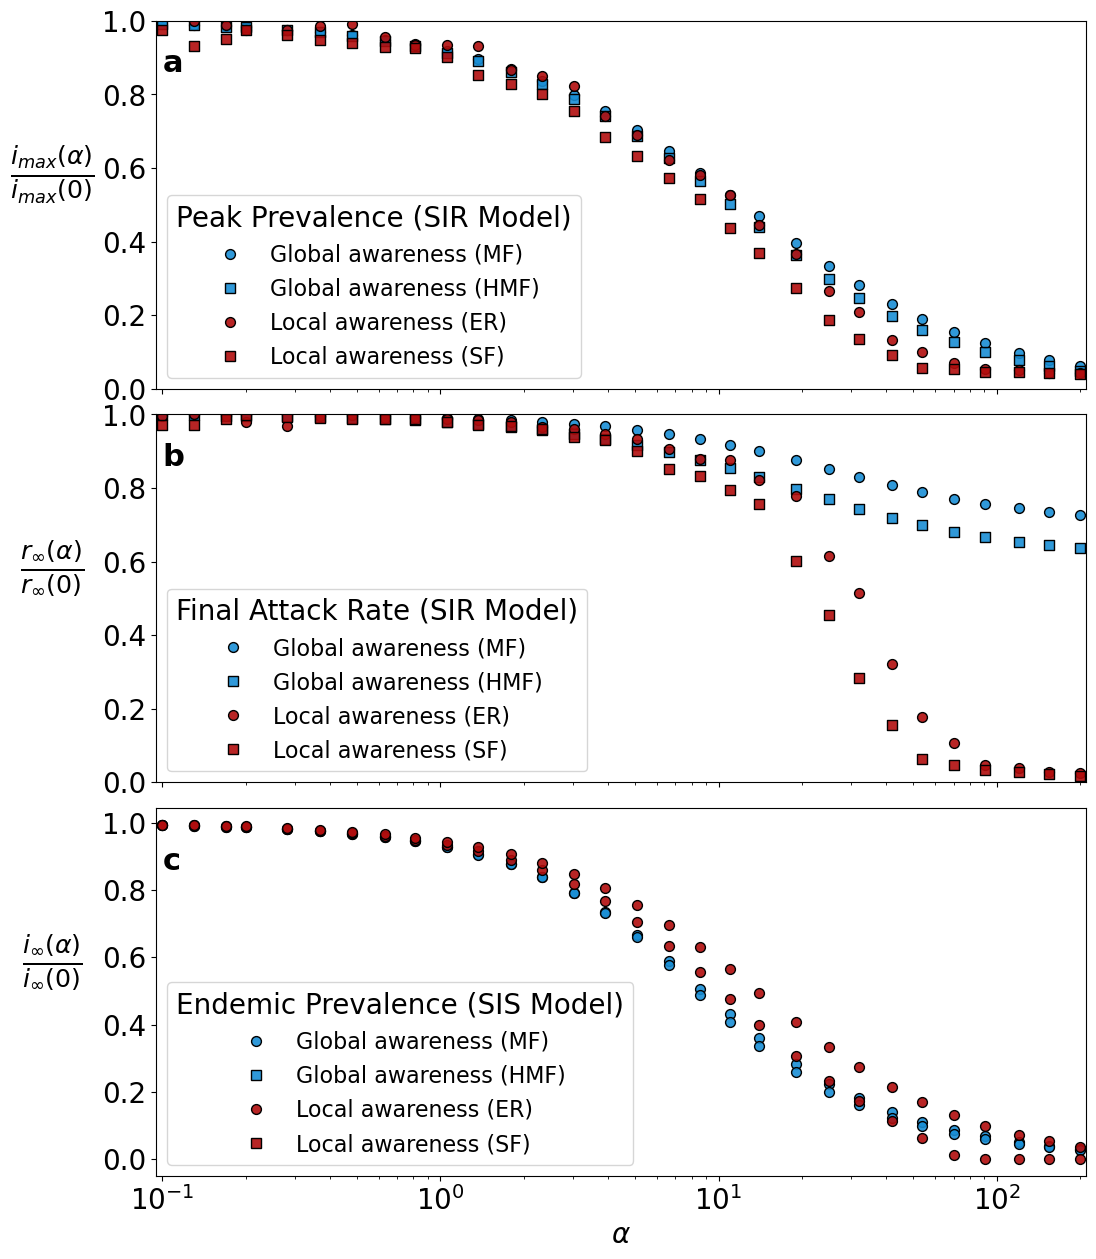

In [97]:
from matplotlib.lines import Line2D

if R_INF == True and I_MAX == True:
    
    alpha_grid = []

    random_sir_path    = "./output_prova/random_sir/"
    scalefree_sir_path = "./output_prova/scalefree_sir"
    random_sis_path    = "./output/random_sis/"
    scalefree_sis_path = "./output/scalefree_sis"

    for dirname in os.listdir(random_sir_path):
        if os.path.isdir(random_sir_path+dirname): # Check that it's actually a directory
            alpha_grid.append(float(dirname.replace("alpha=", "")))

    alpha_grid.sort()        
    alpha_grid = np.array(alpha_grid)

    fontsize = 20
    bigfontsize = 26
    linewidth = 1
    markersize = 50

    c1 = "#b10d0dff" # red
    c1_light = np.array(mpl.colors.to_rgba(c1))
    c1_light[3] *= 0.9
    c2 = "#198ed5ff" # blue
    c2_light = np.array(mpl.colors.to_rgba(c2))
    c2_light[3] *= 0.9

    plt.rcParams['legend.title_fontsize'] = 24

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15), sharex='col', sharey='row')
    fig.subplots_adjust(hspace=0.07)
    plt.setp([a.get_xticklabels() for a in fig.axes[:-2]], visible=True)

    for ax in fig.axes:
        ax.tick_params(axis='both', which='both', labelsize = fontsize)
        ax.set_xscale("log")

    ax3.set_xlabel('$\\alpha$', fontsize = fontsize)

    ax1.set_ylabel(r'$\frac {{ i_{max}(\alpha) }}{{i_{max}(0)}}$', fontsize = bigfontsize, labelpad = 36).set_rotation(0)
    ax2.set_ylabel(r'$\frac {{ r_{\infty}(\alpha) }}{{r_{\infty}(0)}}$', fontsize = bigfontsize, labelpad = 36).set_rotation(0)
    ax3.set_ylabel(r'$\frac {{ i_{\infty}(\alpha) }}{{i_{\infty}(0)}}$', fontsize = bigfontsize, labelpad = 36).set_rotation(0)

    legend_elements = [
        Line2D([0], [0],  label='Global awareness (MF)' , marker='o', color=c2_light, markerfacecolor=c2_light, markeredgecolor='k', markersize=np.sqrt(markersize),linestyle=' '),
        Line2D([0], [0],  label='Global awareness (HMF)', marker='s', color=c2_light, markerfacecolor=c2_light, markeredgecolor='k', markersize=np.sqrt(markersize),linestyle=' '),
        Line2D([0], [0],  label='Local awareness (ER)'  , marker='o', color=c1_light, markerfacecolor=c1_light, markeredgecolor='k', markersize=np.sqrt(markersize),linestyle=' '),
        Line2D([0], [0],  label='Local awareness (SF)'  , marker='s', color=c1_light, markerfacecolor=c1_light, markeredgecolor='k', markersize=np.sqrt(markersize),linestyle=' ')
    ]
    
    ax1.legend(handles=legend_elements, prop={'size': 16}, loc='lower left', title='Peak Prevalence (SIR Model)'   , title_fontsize=fontsize, fontsize=fontsize)
    ax2.legend(handles=legend_elements, prop={'size': 16}, loc='lower left', title='Final Attack Rate (SIR Model)' , title_fontsize=fontsize, fontsize=fontsize)
    ax3.legend(handles=legend_elements, prop={'size': 16}, loc='lower left', title='Endemic Prevalence (SIS Model)', title_fontsize=fontsize, fontsize=fontsize)
    
    for idx, alpha in enumerate(alpha_grid):
        print("", end='\r')
        print(" Simulating alpha = {:.2f} ({}/{})".format(alpha, idx+1, len(alpha_grid)), end='\r')

        # MF
        tt, result_MF, a, eradicated = simulate_MF('sir', t_max, beta, mu, alpha, delta, i0, a_steps, dt)
        _,  result_sis_MF, _, _ = simulate_MF('sis', t_max, beta, mu, alpha, delta, i0, a_steps, dt)
        i_inf = result_sis_MF["i"][-1]
        
        if alpha == 0:
            MF_i_max_0 = max(result_MF["i"])
            r_inf_0_MF = result_MF["r"][-1]
            i_inf_0_MF = i_inf

        else:
            ax1.scatter(alpha, max(result_MF["i"])/MF_i_max_0,
                       linewidth=linewidth, facecolor=c2_light, marker = "o",
                       s=markersize, edgecolor="k")
            ax2.scatter(alpha, result_MF["r"][-1]/r_inf_0_MF,
                       linewidth=linewidth, facecolor=c2_light,
                       marker = "o", s=markersize,
                       edgecolor="k")
            ax3.scatter(alpha, i_inf/i_inf_0_MF, linewidth=linewidth, facecolor=c2_light,
                       marker = "o", s=markersize,
                       edgecolor="k")

        # HMF

        tt, result_HMF, a, theta, eradicated = simulate_HMF('sir', t_max, beta, mu, alpha, delta, i0, degrees, p_k, a_steps, dt)
        _, result_sis_HMF, _, _, _ = simulate_HMF('sis', t_max, beta, mu, alpha, delta, i0, degrees, p_k, a_steps, dt)

        res_i_tot = np.vstack(([np.pad(result_HMF["i"][k]*p_k[k],[(0, len(tt)-len(result_HMF["i"][k]))], mode='constant') # constant mode 
                          for k in degrees])).sum(axis=0)    # defaults to 0
        res_r_tot = np.vstack(([np.pad(result_HMF["r"][k]*p_k[k],[(0, len(tt)-len(result_HMF["r"][k]))], mode='constant') # constant mode 
                  for k in degrees])).sum(axis=0)
        i_inf = np.vstack([result_sis_HMF["i"][k]*p_k[k] for k in degrees]).sum(axis=0)[-1]

        if alpha == 0:
            HMF_i_max_0 = max(res_i_tot)
            r_inf_0_HMF = res_r_tot[-1]
            i_inf_0_HMF = i_inf

        else:

            ax1.scatter(alpha, max(res_i_tot)/HMF_i_max_0,
                       linewidth=linewidth, facecolor=c2_light, marker = "s",
                       s=markersize, edgecolor="k")
            ax2.scatter(alpha, res_r_tot[-1]/r_inf_0_HMF,
                       linewidth=linewidth, facecolor=c2_light, marker = "s",
                       s=markersize, edgecolor="k")
            ax3.scatter(alpha, i_inf/i_inf_0_HMF, linewidth=linewidth, facecolor=c2_light,
                       marker = "o", s=markersize,
                       edgecolor="k")

        # Random Network

        random_sir_matrix = np.load(random_sir_path+"/alpha="+str(alpha)+"/simulations.npy")
        r_inf = np.load(random_sir_path+"/alpha="+str(alpha)+"/r_inf.npy")
        i_inf = np.load(random_sis_path+"/alpha="+str(alpha)+"/i_inf.npy")

        if alpha == 0:
            random_i_max_0 = np.mean([max(run) for run in random_sir_matrix])
            r_inf_0_random = np.mean(r_inf) # mean value of r_inf with alpha = 0
            i_inf_0_random = np.mean(i_inf)
                
        else:
            i_max = np.mean([max(run) for run in random_sir_matrix])
            r_inf_mean = np.mean(r_inf) # mean value of r_inf
            i_inf_mean = np.mean(i_inf)
            ax1.scatter(alpha, i_max/random_i_max_0,
                       linewidth=linewidth, facecolor=c1_light, marker = "o",
                       s=markersize, edgecolor="k")
            ax2.scatter(alpha, r_inf_mean/r_inf_0_random,
                    linewidth=linewidth, facecolor=c1_light, marker = "o",
                    s=markersize, edgecolor="k")
            ax3.scatter(alpha, i_inf_mean/i_inf_0_random,
                    linewidth=linewidth, facecolor=c1_light, marker = "o",
                    s=markersize, edgecolor="k")


        # Scale-Free Network

        scalefree_sir_matrix = np.load(scalefree_sir_path+"/alpha="+str(alpha)+"/simulations.npy")
        r_inf = np.load(scalefree_sir_path+"/alpha="+str(alpha)+"/r_inf.npy")
        i_inf = np.load(scalefree_sis_path+"/alpha="+str(alpha)+"/i_inf.npy")

        if alpha == 0:
            scalefree_i_max_0 = np.mean([max(run) for run in scalefree_sir_matrix])
            r_inf_0_scalefree = np.mean(r_inf)
            i_inf_0_scalefree = np.mean(i_inf)

        else:
            i_max = np.mean([max(run) for run in scalefree_sir_matrix])
            r_inf_mean = np.mean(r_inf) # mean value of r_inf
            i_inf_mean = np.mean(i_inf)
            ax2.scatter(alpha, np.mean(r_inf)/r_inf_0_scalefree,
                    linewidth=linewidth, facecolor=c1_light,
                    marker = "s", s=markersize, edgecolor="k")
            ax1.scatter(alpha, i_max/scalefree_i_max_0,
                       linewidth=linewidth, facecolor=c1_light, marker = "s",
                       s=markersize, edgecolor="k")
            ax3.scatter(alpha, i_inf_mean/i_inf_0_scalefree,
                    linewidth=linewidth, facecolor=c1_light, marker = "o",
                    s=markersize, edgecolor="k")

    alpha_min = min(alpha_grid)
    alpha_max = max(alpha_grid)

    ax1.text(1e-1, 0.86, r"$\bf{a}$", horizontalalignment='left', fontsize=22)
    ax2.text(1e-1, 0.86, r"$\bf{b}$", horizontalalignment='left', fontsize=22)
    ax3.text(1e-1, 0.86, r"$\bf{c}$", horizontalalignment='left', fontsize=22)
    
    ax1.set_xlim(0.095, 210)
    ax2.set_xlim(0.095, 210)
    ax3.set_xlim(0.095, 210)

    ax1.set_ylim(0, 1)
    ax2.set_ylim(0, 1)

    #fig.tight_layout()
    #plt.savefig("../Figures/subplot/subplot.pdf", bbox_inches='tight')
    plt.show()

25.0


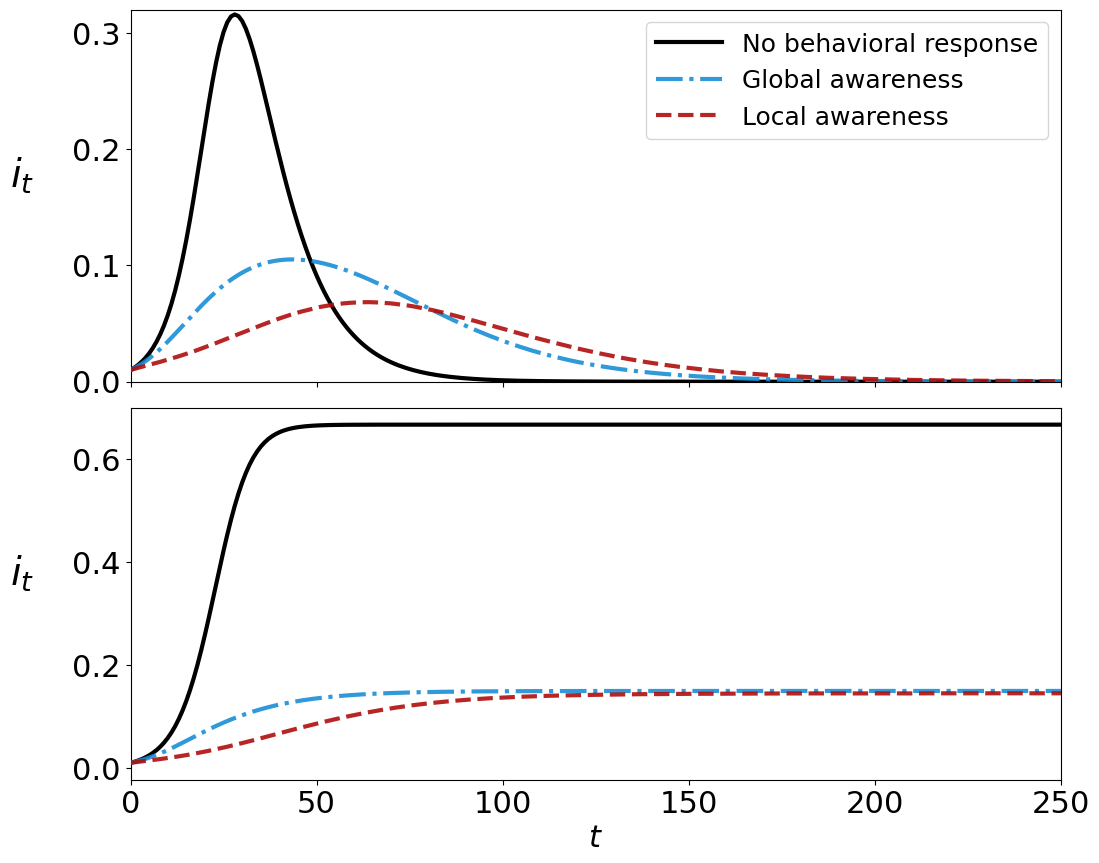

In [78]:
    
    t_lim = 250
    alpha_grid = []

    random_sir_path = "./output/random_sir/"
    scalefree_sir_path = "./output/scalefree_sir"

    for dirname in os.listdir(random_sir_path):
        if os.path.isdir(random_sir_path+dirname): # Check that it's actually a directory
            alpha_grid.append(float(dirname.replace("alpha=", "")))

    alpha_grid.sort()        
    alpha_grid = np.array(alpha_grid)

    linewidth = 3
    transparency = 1

    c1 = "#b10d0dff" # red
    c1_light = np.array(mpl.colors.to_rgba(c1))
    c1_light[3] *= 0.9
    c2 = "#198ed5ff" # blue
    c2_light = np.array(mpl.colors.to_rgba(c2))
    c2_light[3] *= 0.9

    plt.rcParams['legend.title_fontsize'] = 24

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex='col', sharey='row')
    fig.subplots_adjust(hspace=0.07)
    
    for idx, value in enumerate([alpha_grid[0], alpha_grid[22]]):
        
        alpha = value

        # MF
        tt, result_MF, a, eradicated = simulate_MF('sir', t_max, beta, mu, alpha, delta, i0, a_steps, dt)
        tt_sis, result_MF_sis, _, _  = simulate_MF('sis', t_max, beta, mu, alpha, delta, i0, a_steps, dt)

        if alpha == 0:
            ax1.plot(tt ,result_MF["i"], linewidth=linewidth, linestyle="-", alpha=transparency,
                    color="k", zorder=-99, label="No behavioral response",
                    #path_effects=[pe.Stroke(linewidth=linewidth+2, foreground=c2_light, alpha=transparency), pe.Normal()]
                   )
            ax2.plot(tt_sis ,result_MF_sis["i"], linewidth=linewidth, linestyle="-", alpha=transparency,
                    color="k", zorder=-99, label="No behavioral response",
                    #path_effects=[pe.Stroke(linewidth=linewidth+2, foreground=c2_light, alpha=transparency), pe.Normal()]
                   )
            pass
        else:
            print(alpha)
            ax1.plot(tt ,result_MF["i"], linewidth=linewidth, linestyle="-.",
                    color=c2_light, zorder=10, label="Global awareness")
            ax2.plot(tt_sis ,result_MF_sis["i"], linewidth=linewidth, linestyle="-.",
                    color=c2_light, zorder=10, label="Global awareness")
    
        # Random Network
        
        random_sir_matrix = np.load(random_sir_path+"/alpha="+str(alpha)+"/simulations.npy")
        tt_random_sir = np.linspace(0, dt*random_sir_matrix.shape[1], random_sir_matrix.shape[1])

        random_sis_matrix = np.load(random_sis_path+"/alpha="+str(alpha)+"/simulations.npy")
        tt_random_sis = np.linspace(0, dt*random_sir_matrix.shape[1], random_sir_matrix.shape[1])

        boxplot_dict = {"t_plot": [],
                        "i": []}

        if alpha == 0:
            # Only plot alpha=0 of MF for readability
            pass
        else:
            ax1.plot(tt_random_sir ,np.mean(random_sir_matrix, axis=0), linewidth=linewidth, linestyle="--",
                    color=c1_light, zorder=10, label="Local awareness")
            ax2.plot(tt_random_sis ,np.mean(random_sis_matrix, axis=0), linewidth=linewidth, linestyle="--",
                    color=c1_light, zorder=10, label="Local awareness")

        for ax in fig.axes:
            ax.set_xlim(0, t_lim)
            ax.set_ylabel(r'$i_{t}$', fontsize = bigfontsize, labelpad = 36).set_rotation(0)
            ax.tick_params(axis='both', which='both', labelsize = fontsize)      
            
        ax2.set_xlabel('$t$', fontsize = fontsize)

        ax1.set_ylim(0, 0.32)

        ax1.legend(prop={'size': 16}, loc='upper right', title='SIR Model', fontsize='big')
        ax2.legend(prop={'size': 16}, loc='upper right', title='SIRS Model', fontsize='big')

    plt.savefig("../Figures/epicurves/epicurves.pdf", bbox_inches='tight')
    plt.show()


# SIS